# Step 1 - Define the problem

Objective: 
The objective of this assignment is to implement and evaluate the K-Nearest Neighbours algorithm for classification using the given datasets
Dataset:
Need to Classify the animal type
Tasks:
1. Analyse the data using the visualizations
2. Preprocess the data by handling missing values & Outliers, if any.
3. Split the dataset into training and testing sets (80% training, 20% testing).
4. Implement the K-Nearest Neighbours algorithm using a machine learning library like scikit-learn On training dataset
5. Choose an appropriate distance metric and value for K.
6. Evaluate the classifier's performance on the testing set using accuracy, precision, recall, and F1-score metrics.
7. Visualize the decision boundaries of the classifier.

Interview Questions:
1. What are the key hyperparameters in KNN?
2. What distance metrics can be used in KNN?



In [2]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import influence_plot

# Step 2 - Collect and Prepare Data(EDA)

In [3]:
zoo_df=pd.read_csv('zoo.csv')

## Step 2.1 - Understand the Dataset                                                      

### Step 2.1.1 Use .head(), .tail(), .info(), and .shape() to get a feel for it



In [4]:
zoo_df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [5]:
zoo_df.shape

(101, 18)

In [6]:
zoo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [7]:
zoo_df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


### Step 2.1.2 check the distinct values in each column

In [8]:
zoo_df.nunique()

animal name    100
hair             2
feathers         2
eggs             2
milk             2
airborne         2
aquatic          2
predator         2
toothed          2
backbone         2
breathes         2
venomous         2
fins             2
legs             6
tail             2
domestic         2
catsize          2
type             7
dtype: int64

In [9]:
zoo_df.apply(pd.unique) # it will show distinct values in every feature

animal name    [aardvark, antelope, bass, bear, boar, buffalo...
hair                                                      [1, 0]
feathers                                                  [0, 1]
eggs                                                      [0, 1]
milk                                                      [1, 0]
airborne                                                  [0, 1]
aquatic                                                   [0, 1]
predator                                                  [1, 0]
toothed                                                   [1, 0]
backbone                                                  [1, 0]
breathes                                                  [1, 0]
venomous                                                  [0, 1]
fins                                                      [0, 1]
legs                                          [4, 0, 2, 6, 8, 5]
tail                                                      [0, 1]
domestic                 

In [10]:
for col in zoo_df.columns:
    print(col, ":", zoo_df[col].unique())

animal name : ['aardvark' 'antelope' 'bass' 'bear' 'boar' 'buffalo' 'calf' 'carp'
 'catfish' 'cavy' 'cheetah' 'chicken' 'chub' 'clam' 'crab' 'crayfish'
 'crow' 'deer' 'dogfish' 'dolphin' 'dove' 'duck' 'elephant' 'flamingo'
 'flea' 'frog' 'fruitbat' 'giraffe' 'girl' 'gnat' 'goat' 'gorilla' 'gull'
 'haddock' 'hamster' 'hare' 'hawk' 'herring' 'honeybee' 'housefly' 'kiwi'
 'ladybird' 'lark' 'leopard' 'lion' 'lobster' 'lynx' 'mink' 'mole'
 'mongoose' 'moth' 'newt' 'octopus' 'opossum' 'oryx' 'ostrich' 'parakeet'
 'penguin' 'pheasant' 'pike' 'piranha' 'pitviper' 'platypus' 'polecat'
 'pony' 'porpoise' 'puma' 'pussycat' 'raccoon' 'reindeer' 'rhea'
 'scorpion' 'seahorse' 'seal' 'sealion' 'seasnake' 'seawasp' 'skimmer'
 'skua' 'slowworm' 'slug' 'sole' 'sparrow' 'squirrel' 'starfish'
 'stingray' 'swan' 'termite' 'toad' 'tortoise' 'tuatara' 'tuna' 'vampire'
 'vole' 'vulture' 'wallaby' 'wasp' 'wolf' 'worm' 'wren']
hair : [1 0]
feathers : [0 1]
eggs : [0 1]
milk : [1 0]
airborne : [0 1]
aquatic : [0

In [11]:
zoo_df['type'].value_counts()

type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64

In [12]:
zoo_df.columns

Index(['animal name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'type'],
      dtype='object')

In [13]:
for i in zoo_df.select_dtypes(include=int).columns:
    #print("\n", col)
    print(zoo_df[i].value_counts())

hair
0    58
1    43
Name: count, dtype: int64
feathers
0    81
1    20
Name: count, dtype: int64
eggs
1    59
0    42
Name: count, dtype: int64
milk
0    60
1    41
Name: count, dtype: int64
airborne
0    77
1    24
Name: count, dtype: int64
aquatic
0    65
1    36
Name: count, dtype: int64
predator
1    56
0    45
Name: count, dtype: int64
toothed
1    61
0    40
Name: count, dtype: int64
backbone
1    83
0    18
Name: count, dtype: int64
breathes
1    80
0    21
Name: count, dtype: int64
venomous
0    93
1     8
Name: count, dtype: int64
fins
0    84
1    17
Name: count, dtype: int64
legs
4    38
2    27
0    23
6    10
8     2
5     1
Name: count, dtype: int64
tail
1    75
0    26
Name: count, dtype: int64
domestic
0    88
1    13
Name: count, dtype: int64
catsize
0    57
1    44
Name: count, dtype: int64
type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64


In [14]:
for i in zoo_df.select_dtypes(include=int).columns:
    print("\n", ' ') # this will provide spece after evry record so the view can be understandable
    print(zoo_df[i].value_counts())




  
hair
0    58
1    43
Name: count, dtype: int64

  
feathers
0    81
1    20
Name: count, dtype: int64

  
eggs
1    59
0    42
Name: count, dtype: int64

  
milk
0    60
1    41
Name: count, dtype: int64

  
airborne
0    77
1    24
Name: count, dtype: int64

  
aquatic
0    65
1    36
Name: count, dtype: int64

  
predator
1    56
0    45
Name: count, dtype: int64

  
toothed
1    61
0    40
Name: count, dtype: int64

  
backbone
1    83
0    18
Name: count, dtype: int64

  
breathes
1    80
0    21
Name: count, dtype: int64

  
venomous
0    93
1     8
Name: count, dtype: int64

  
fins
0    84
1    17
Name: count, dtype: int64

  
legs
4    38
2    27
0    23
6    10
8     2
5     1
Name: count, dtype: int64

  
tail
1    75
0    26
Name: count, dtype: int64

  
domestic
0    88
1    13
Name: count, dtype: int64

  
catsize
0    57
1    44
Name: count, dtype: int64

  
type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64


### Step 2.1.3 Check data types: numerical, categorical, datetime,remove unwanted columns and rows, remove duplicate rows, convert the datatype etc.

- All the features are having correct datatypes
- All the feaures are having data in valid format
- so no need to change the data type of any feature

- animal name - is unwanted feature we can remove this 

In [15]:
zoo_df_1=zoo_df.drop('animal name',axis=1).copy()

In [16]:
zoo_df_1.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [17]:
zoo_df.duplicated().sum()

np.int64(0)

In [18]:
zoo_df.duplicated().value_counts()

False    101
Name: count, dtype: int64

- No duplcate recordddds are available in given dataset

##  Step 2.3 - Analyze Target Variable 

In [19]:
zoo_df['type'].head()

0    1
1    1
2    4
3    1
4    1
Name: type, dtype: int64

In [20]:
zoo_df['type'].value_counts()

type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64

- So this is basically multiclass classification
- The dataset is imbalanced, with a strong dominance of class 1 and moderate dominance of class 2.

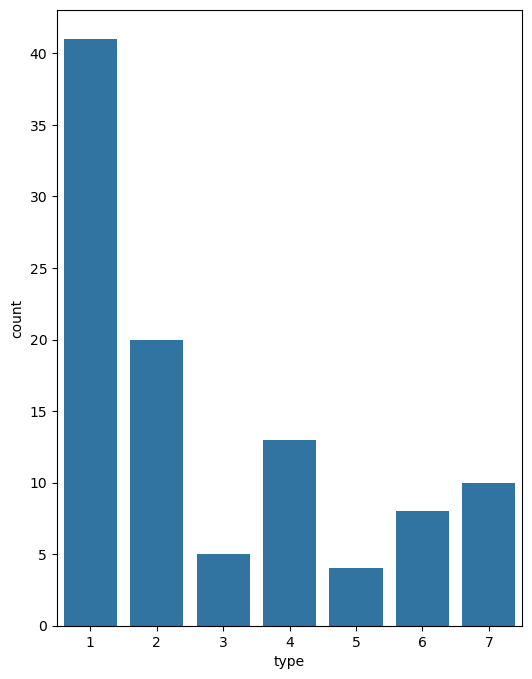

In [21]:
plt.figure(figsize=(6,8))
sns.countplot(zoo_df,x='type')
plt.show()

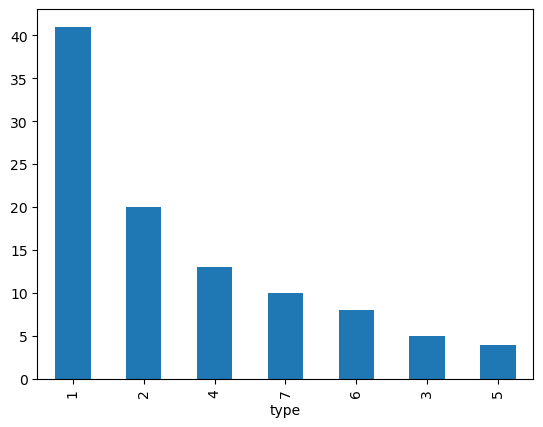

In [22]:
zoo_df['type'].value_counts().plot(kind='bar')
plt.show()

- By looking at the above graph we can say that major animals are belongas to type 1,2,4

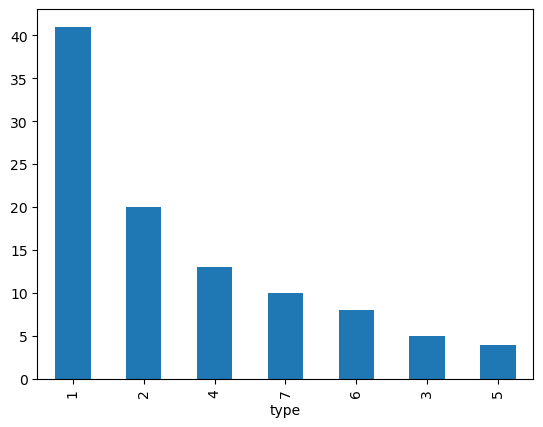

In [23]:
zoo_df['type'].value_counts().plot(kind='bar')
plt.show()

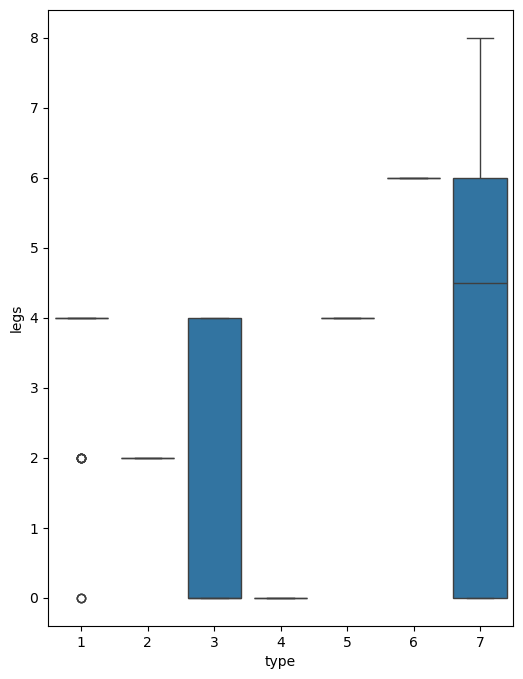

In [24]:
plt.figure(figsize=(6,8))
sns.boxplot(zoo_df,x='type',y='legs')
plt.show()

## Step 2.4 - Univariate Analysis (Single Variable)  - see the distribution/count/histogram of any one variable

In [25]:
zoo_df.apply(pd.unique)

animal name    [aardvark, antelope, bass, bear, boar, buffalo...
hair                                                      [1, 0]
feathers                                                  [0, 1]
eggs                                                      [0, 1]
milk                                                      [1, 0]
airborne                                                  [0, 1]
aquatic                                                   [0, 1]
predator                                                  [1, 0]
toothed                                                   [1, 0]
backbone                                                  [1, 0]
breathes                                                  [1, 0]
venomous                                                  [0, 1]
fins                                                      [0, 1]
legs                                          [4, 0, 2, 6, 8, 5]
tail                                                      [0, 1]
domestic                 

In [26]:
for i in zoo_df.select_dtypes(include=int).columns:
    print("\n", ' ') # this will provide spece after evry record so the view can be understandable
    print(zoo_df[i].value_counts())


  
hair
0    58
1    43
Name: count, dtype: int64

  
feathers
0    81
1    20
Name: count, dtype: int64

  
eggs
1    59
0    42
Name: count, dtype: int64

  
milk
0    60
1    41
Name: count, dtype: int64

  
airborne
0    77
1    24
Name: count, dtype: int64

  
aquatic
0    65
1    36
Name: count, dtype: int64

  
predator
1    56
0    45
Name: count, dtype: int64

  
toothed
1    61
0    40
Name: count, dtype: int64

  
backbone
1    83
0    18
Name: count, dtype: int64

  
breathes
1    80
0    21
Name: count, dtype: int64

  
venomous
0    93
1     8
Name: count, dtype: int64

  
fins
0    84
1    17
Name: count, dtype: int64

  
legs
4    38
2    27
0    23
6    10
8     2
5     1
Name: count, dtype: int64

  
tail
1    75
0    26
Name: count, dtype: int64

  
domestic
0    88
1    13
Name: count, dtype: int64

  
catsize
0    57
1    44
Name: count, dtype: int64

  
type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64


In [27]:
zoo_df[zoo_df['legs']==5]

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
85,starfish,0,0,1,0,0,1,1,0,0,0,0,0,5,0,0,0,7


- 93% animals are venomous 
- 80% animals are not having feathers
- 77% animals can not fly. so feathers feature and airborne feature gives similar information, so we can drop one of them.
- 60% animals does not gives milk

## Step 2.5 - Check for Missing Values 

In [28]:
zoo_df.isnull().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

- No missing values

## Step 2.4 - Encode Categorical Variables

In [29]:
zoo_df_1.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


- As the all the features are INT and having values in machine readeable format so encoding is not required.

##  Step 2.5 - Bivariate/Multivariate Analysis – compare any feature with target variable.

- Hair

In [30]:
hair_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['hair'])
print(hair_ct)

hair   0   1
type        
1      2  39
2     20   0
3      5   0
4     13   0
5      4   0
6      4   4
7     10   0


- Major of the animals dont have hairs

<Figure size 600x400 with 0 Axes>

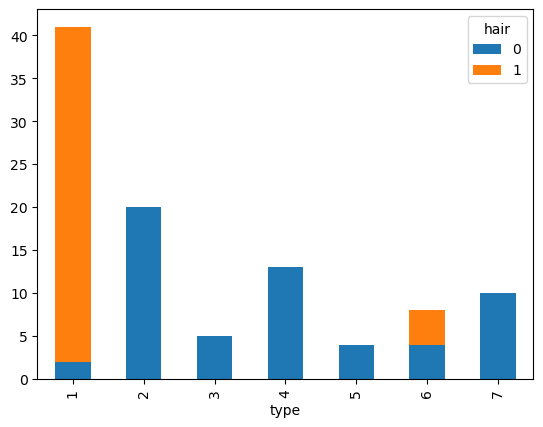

In [31]:
plt.figure(figsize=(6,4))
hair_ct.plot(kind='bar',stacked=True)
plt.show()

- feathers

In [32]:

feathers_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['feathers'])
feathers_ct

feathers,0,1
type,,
1,41,0
2,0,20
3,5,0
4,13,0
5,4,0
6,8,0
7,10,0


<Figure size 200x200 with 0 Axes>

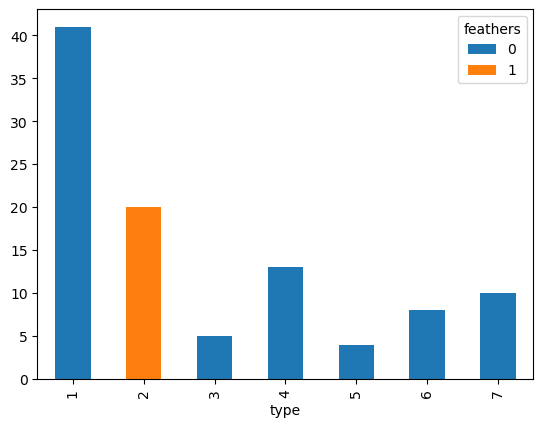

In [33]:
plt.figure(figsize=(2,2))
feathers_ct.plot(stacked=True,kind='bar')
plt.show()

- Only type 2 has feather
  - MOst of the animals does not have feather, so we can conclude this feature can play important role while predicting type.

- Eggs

In [34]:
eggs_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['eggs'])
print(eggs_ct)


eggs   0   1
type        
1     40   1
2      0  20
3      1   4
4      0  13
5      0   4
6      0   8
7      1   9


<Axes: xlabel='type'>

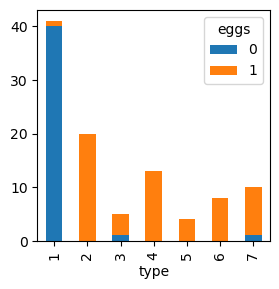

In [35]:
eggs_ct.plot(kind='bar', stacked=True, figsize=(3,3))

- MOst of the animals does lay eggs, so we can conclude this feature can play important role while predicting type.

- milk

In [36]:
milk_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['milk'])
print(milk_ct)

milk   0   1
type        
1      0  41
2     20   0
3      5   0
4     13   0
5      4   0
6      8   0
7     10   0


<Axes: xlabel='type'>

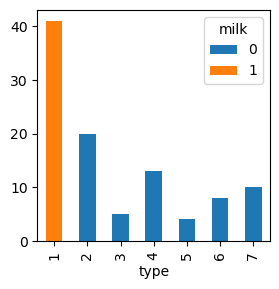

In [37]:
milk_ct.plot(kind='bar',stacked=True,figsize=(3,3))

- MOst of the animals gives milk, so we can conclude this feature can play important role while predicting type.
- Only type1 animals are producing milk, so this can be can be a strong feature to identify type1 animal

- airborne

In [38]:
airborne_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['airborne'])
print(airborne_ct)

airborne   0   1
type            
1         39   2
2          4  16
3          5   0
4         13   0
5          4   0
6          2   6
7         10   0


<Axes: xlabel='type'>

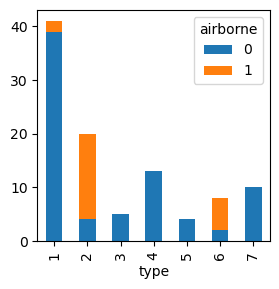

In [39]:
airborne_ct.plot(kind='bar',stacked=True,figsize=(3,3))

- Most of the animals can not airborne, so we can conclude this feature can play important role while predicting type.

- aquatic

aquatic   0   1
type           
1        35   6
2        14   6
3         4   1
4         0  13
5         0   4
6         8   0
7         4   6


<Axes: xlabel='type'>

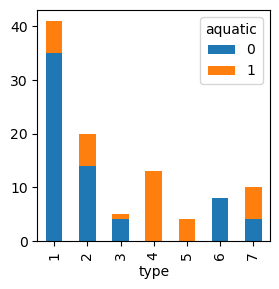

In [40]:
aquatic_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['aquatic'])
print(aquatic_ct)
aquatic_ct.plot(kind='bar',stacked=True,figsize=(3,3))

predator   0   1
type            
1         19  22
2         11   9
3          1   4
4          4   9
5          1   3
6          7   1
7          2   8


<Axes: xlabel='type'>

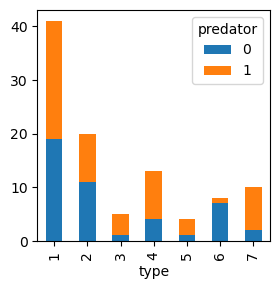

In [41]:
predator_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['predator'])
print(predator_ct)
predator_ct.plot(kind='bar',stacked=True,figsize=(3,3))

toothed   0   1
type           
1         1  40
2        20   0
3         1   4
4         0  13
5         0   4
6         8   0
7        10   0


<Axes: xlabel='type'>

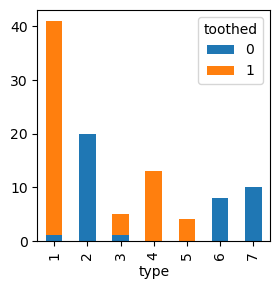

In [42]:
toothed_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['toothed'])
print(toothed_ct)
toothed_ct.plot(kind='bar',stacked=True,figsize=(3,3))

backbone   0   1
type            
1          0  41
2          0  20
3          0   5
4          0  13
5          0   4
6          8   0
7         10   0


<Axes: xlabel='type'>

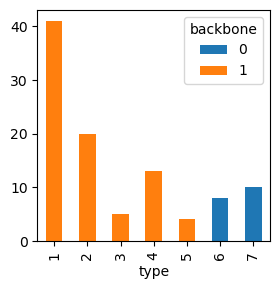

In [43]:
backbone_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['backbone'])
print(backbone_ct)
backbone_ct.plot(kind='bar',stacked=True,figsize=(3,3))

- MOst of the animals are with backbone, so this can be good predictor

breathes   0   1
type            
1          0  41
2          0  20
3          1   4
4         13   0
5          0   4
6          0   8
7          7   3


<Axes: xlabel='type'>

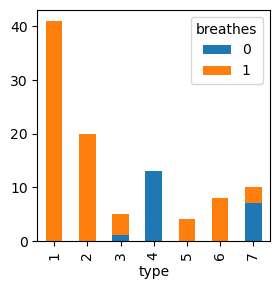

In [44]:
breathes_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['breathes'])
print(breathes_ct)
breathes_ct.plot(kind='bar',stacked=True,figsize=(3,3))

venomous   0  1
type           
1         41  0
2         20  0
3          3  2
4         12  1
5          3  1
6          6  2
7          8  2


<Axes: xlabel='type'>

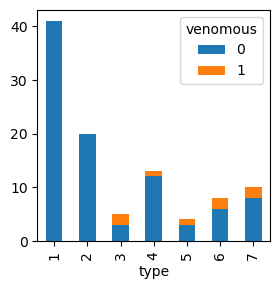

In [45]:
venomous_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['venomous'])
print(venomous_ct)
venomous_ct.plot(kind='bar',stacked=True,figsize=(3,3))

- Most of the animals are venomous, so this can be a goood predictor.

fins   0   1
type        
1     37   4
2     20   0
3      5   0
4      0  13
5      4   0
6      8   0
7     10   0


<Axes: xlabel='type'>

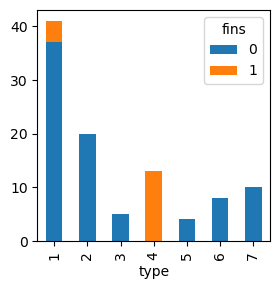

In [46]:
fins_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['fins'])
print(fins_ct)
fins_ct.plot(kind='bar',stacked=True,figsize=(3,3))

In [47]:
zoo_df_1.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


legs   0   2   4  5  6  8
type                     
1      3   7  31  0  0  0
2      0  20   0  0  0  0
3      3   0   2  0  0  0
4     13   0   0  0  0  0
5      0   0   4  0  0  0
6      0   0   0  0  8  0
7      4   0   1  1  2  2


<Axes: xlabel='type'>

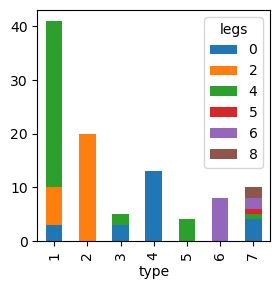

In [48]:
legs_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['legs'])
print(legs_ct)
legs_ct.plot(kind='bar',stacked=True,figsize=(3,3))

tail  0   1
type       
1     6  35
2     0  20
3     0   5
4     0  13
5     3   1
6     8   0
7     9   1


<Axes: xlabel='type'>

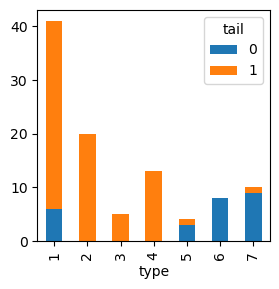

In [49]:
tail_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['tail'])
print(tail_ct)
tail_ct.plot(kind='bar',stacked=True,figsize=(3,3))

domestic   0  1
type           
1         33  8
2         17  3
3          5  0
4         12  1
5          4  0
6          7  1
7         10  0


<Axes: xlabel='type'>

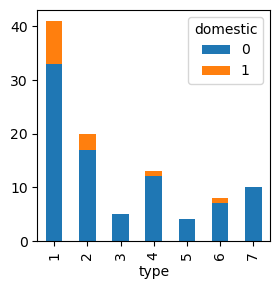

In [50]:
domestic_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['domestic'])
print(domestic_ct)
domestic_ct.plot(kind='bar',stacked=True,figsize=(3,3))

catsize   0   1
type           
1         9  32
2        14   6
3         4   1
4         9   4
5         4   0
6         8   0
7         9   1


<Axes: xlabel='type'>

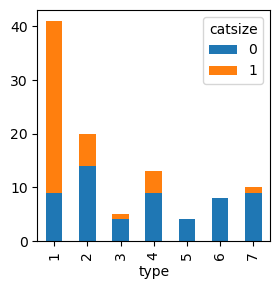

In [51]:
catsize_ct=pd.crosstab(zoo_df_1['type'],zoo_df_1['catsize'])
print(catsize_ct)
catsize_ct.plot(kind='bar',stacked=True,figsize=(3,3))

In [52]:
pd.crosstab(zoo_df['feathers'], zoo_df['airborne'])

airborne,0,1
feathers,,
0,73,8
1,4,16


In [53]:
pd.crosstab(
    zoo_df['feathers'],
    zoo_df['airborne'],
    normalize='index'
)

airborne,0,1
feathers,,
0,0.901235,0.098765
1,0.200000,0.800000


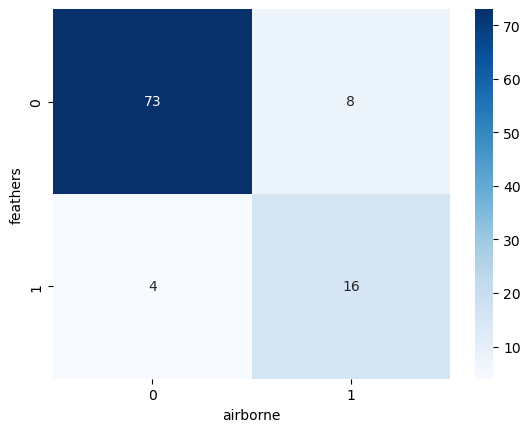

In [54]:
ct = pd.crosstab(zoo_df['feathers'], zoo_df['airborne'])

sns.heatmap(ct, annot=True, cmap='Blues', fmt='d')
plt.show()

##  Step 2.7 - Outlier Detection 

- As all the features are categorical so can not perform outlier detection here

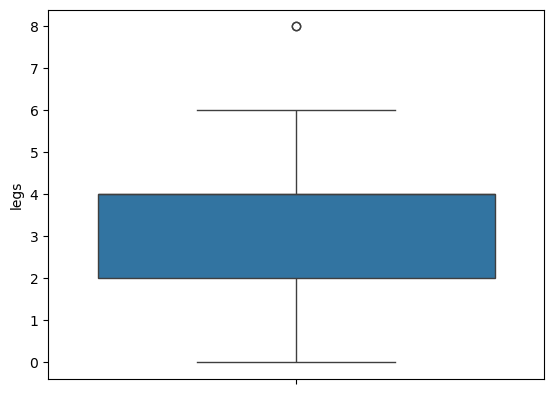

In [55]:
sns.boxplot(y=zoo_df['legs'])
plt.show()

## Step 2.8 – Encoding the values

- All the features are in numerical and machine readable format so no need to encode

##  Step 2.10 - Feature Relationships & Correlations

- As all the features are having binary values we not check the feature relationship

In [56]:
zoo_df_1.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


##  Step 2.11 – Feature selection 

In [83]:
from sklearn.feature_selection import SelectKBest,chi2,f_classif,f_regression
selection_model=SelectKBest(k=7,score_func=f_classif)

In [84]:
x=zoo_df_1.iloc[:,:-1]
y=zoo_df_1.iloc[:,-1]

In [85]:
x.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1


In [86]:
selection_model.fit_transform(x,y)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


array([[1, 0, 0, 1, 1, 1, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [0, 0, 1, 0, 1, 1, 0],
       [1, 0, 0, 1, 1, 1, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [0, 0, 1, 0, 1, 1, 0],
       [0, 0, 1, 0, 1, 1, 0],
       [1, 0, 0, 1, 1, 1, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [0, 1, 1, 0, 0, 1, 1],
       [0, 0, 1, 0, 1, 1, 0],
       [0, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 1, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [0, 0, 1, 0, 1, 1, 0],
       [0, 0, 0, 1, 1, 1, 1],
       [0, 1, 1, 0, 0, 1, 1],
       [0, 1, 1, 0, 0, 1, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [0, 1, 1, 0, 0, 1, 1],
       [0, 0, 1, 0, 0, 0, 1],
       [0, 0, 1, 0, 1, 1, 1],
       [0, 0, 1, 0, 1, 1, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [0, 0, 1, 0, 0, 0, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [1, 0, 0, 1, 1, 1, 1],
       [0,

In [87]:
selection_model.scores_

array([ 83.46571782,          inf, 127.99263819,          inf,
        27.74963211,  13.32005359,   2.15022584, 197.48931926,
                inf,  74.19335382,   3.65435365,  45.69619124,
        19.76654805,  28.99922618,   0.78373461,   9.12236721])

In [88]:
selection_model.get_feature_names_out() 

array(['hair', 'feathers', 'eggs', 'milk', 'toothed', 'backbone',
       'breathes'], dtype=object)

In [91]:
feat_imp=pd.DataFrame()
feat_imp['features']=x.columns
feat_imp['importances']=selection_model.scores_
feat_imp.sort_values(by='importances',ascending=False).head(15)

,features,importances
1,feathers,inf
3,milk,inf
8,backbone,inf
7,toothed,197.489319
2,eggs,127.992638
0,hair,83.465718
9,breathes,74.193354
11,fins,45.696191
13,tail,28.999226
4,airborne,27.749632


<Figure size 800x400 with 0 Axes>

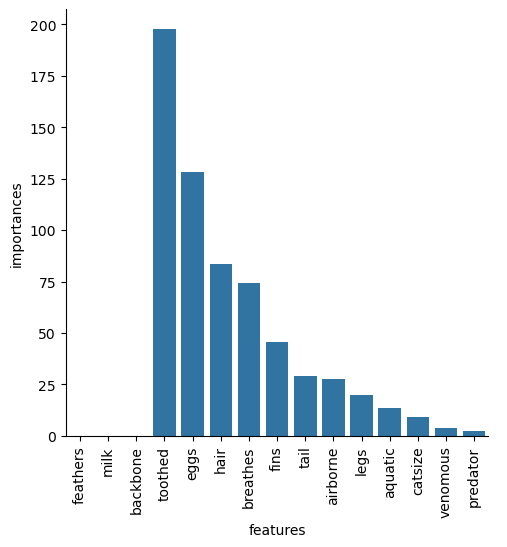

In [93]:
plt.figure(figsize=(8,4))
sns.catplot(feat_imp.sort_values(by='importances',ascending=False).head(15),x='features',y='importances',kind='bar')
plt.xticks(rotation=90)
plt.show()

- According to the select K base feature selection it has suhjjested ['hair', 'feathers', 'eggs', 'milk', 'toothed', 'backbone',
       'breathes']

# Step 3 – Model building

##  Step 3.1 - find out independent and dependent variable

In [94]:
zoo_df_2=zoo_df_1[['hair', 'feathers', 'eggs', 'milk', 'toothed', 'backbone', 'breathes','type']].copy()

In [95]:
zoo_df_2.shape

(101, 8)

In [96]:
zoo_df_2.head()

,hair,feathers,eggs,milk,toothed,backbone,breathes,type
0,1,0,0,1,1,1,1,1
1,1,0,0,1,1,1,1,1
2,0,0,1,0,1,1,0,4
3,1,0,0,1,1,1,1,1
4,1,0,0,1,1,1,1,1


In [97]:
xx=zoo_df_2.iloc[:,:-1]
yy=zoo_df_2.iloc[:,-1]

In [100]:
xx.head()

,hair,feathers,eggs,milk,toothed,backbone,breathes
0,1,0,0,1,1,1,1
1,1,0,0,1,1,1,1
2,0,0,1,0,1,1,0
3,1,0,0,1,1,1,1
4,1,0,0,1,1,1,1


In [101]:
yy.head()

0    1
1    1
2    4
3    1
4    1
Name: type, dtype: int64

##  Step 3.2 split the data into X-train and Y-train

In [102]:
from sklearn.model_selection import train_test_split

In [103]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=72)

In [104]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((80, 16), (21, 16), (80,), (21,))

### 3.2.1 scale the features if required

- Scalling is not required as all the seleccted features having the values  0 and 1

# Step 5 - Choose the Algorithm and Build the model

## Step 5.1 – Find the best parameter

In [106]:
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

In [108]:
model = KNeighborsClassifier()

In [109]:
param_grid = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}

In [110]:



grid_model = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [111]:
grid_model.fit(x_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [122]:
grid_model.best_estimator_

KNeighborsClassifier(metric='euclidean', n_neighbors=3, weights='distance')

In [123]:
grid_model.best_params_

{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}

## Step 6.1 - predict the values for training data(x_train)-yhat_train

In [125]:
model1=KNeighborsClassifier(metric='euclidean', n_neighbors=3, weights='distance')
model1.fit(x_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3, weights='distance')

In [115]:
from sklearn.metrics import confusion_matrix,classification_report

- Prediction with tr5ain data

In [126]:
y_hat_train=model1.predict(x_train)

In [127]:
train_cm=confusion_matrix(y_train,y_hat_train)
train_clf=classification_report(y_train,y_hat_train)

In [128]:
print(train_cm)

[[34  0  0  0  0  0  0]
 [ 0 16  0  0  0  0  0]
 [ 0  0  5  0  0  0  0]
 [ 0  0  0 10  0  0  0]
 [ 0  0  0  0  3  0  0]
 [ 0  0  0  0  0  6  0]
 [ 0  0  0  0  0  0  6]]


In [129]:
print(train_clf)

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        34
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         6

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



- Prediction with test data

In [130]:
y_hat_test=model1.predict(x_test)

In [131]:
test_cm=confusion_matrix(y_test,y_hat_test)
test_clf=classification_report(y_test,y_hat_test)

In [132]:
test_cm

array([[7, 0, 0, 0, 0, 0],
       [0, 4, 0, 0, 0, 0],
       [0, 0, 3, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 2, 0],
       [0, 0, 0, 1, 0, 3]])

In [134]:
print(test_clf)

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       0.50      1.00      0.67         1
           6       1.00      1.00      1.00         2
           7       1.00      0.75      0.86         4

    accuracy                           0.95        21
   macro avg       0.92      0.96      0.92        21
weighted avg       0.98      0.95      0.96        21



- The model achieved 100% training accuracy and 95% test accuracy, indicating excellent predictive performance with only slight overfitting. Most classes were classified perfectly. Lower precision for class 5 and lower recall for class 7 indicate minor difficulties in predicting minority classes due to class imbalance and limited samples. Overall, the model generalizes well on unseen data.

### K fold cross validation - Appplying k folde cross validation to cross check the accuracy 

In [136]:
from sklearn.model_selection import KFold,cross_val_score

In [145]:
cvals=cross_val_score(model1,xx,yy,cv=5,scoring='accuracy')

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


In [146]:
cvals

array([0.95238095, 0.95      , 0.9       , 0.9       , 0.9       ])

In [147]:
cvals.mean()

np.float64(0.9204761904761904)

- As per Kfold cross validation the accuracy in 92%

# K - visualzation

In [150]:
train_acc=[]
test_acc=[]
for i in range(1,10):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    #y_hat_train=model.predict(x_train)
    #y_hat_test=model.predict(x_test)
    train_score=model.score(x_train,y_train)
    test_score=model.score(x_test,y_test)
    train_acc.append(train_score)
    test_acc.append(test_score)

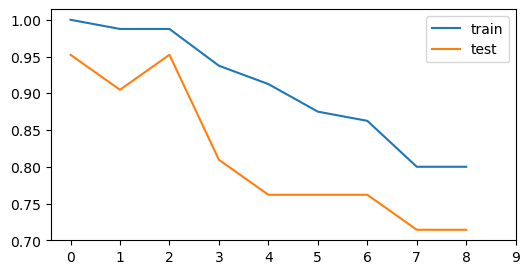

In [152]:

plt.figure(figsize=(6,3))
plt.plot(train_acc,label='train')
plt.plot(test_acc,label='test')
plt.xticks(range(0,10))
plt.legend()
plt.show()

- If we see above graph is showing k=2 value will be good for hyperparamter tuning.
- And the similar value k=3 we have received from grid search cv
                                                         

- 1. What are the key hyperparameters in KNN? - ['n_neighbors','weights','metric']

- 2 What distance metrics can be used in KNN? - ['euclidean','manhattan']
